# Libraries and loading data

In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import pickle
import os
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
Colors = sns.color_palette("colorblind", 16).as_hex()
import matplotlib.pyplot as plt
text_size=26
fig_size_x=24
fig_size_y=14
from scipy.interpolate import interp1d
import pandas as pd
import ast
import time
from collections import defaultdict
import time
from colossus.lss import peaks
from colossus.lss import bias
from colossus.cosmology import cosmology
cosmology.setCosmology('planck18');


# def nested_dict(n, type):
#     if n == 1:
#         return defaultdict(type)
#     else:
#         return defaultdict(lambda: nested_dict(n-1, type))
    
# dataf = nested_dict(5, list)

from IPython.display import Audio

# Define the audio tone
duration = 1.2  # in seconds
freq = 320  # in Hz
sample_rate = 4410  # in samples per second
t = np.linspace(0, duration, int(duration * sample_rate), False)
audio_data = np.sin(2 * np.pi * freq * t)
# Display the audio tone
# Audio(audio_data, rate=sample_rate, autoplay=True)

# Loading Data

In [5]:
Mass_cuts = [1.e12, 5.e12, 1.e13, 2.e13, 3.e13, 4.e13, 5.e13, 6.e13, 7.e13, 8.e13, 9.e13, 1.e14, 2.e14, 5.e14,7.e14, 1.e15];

df_large=[]
df_small=[]
df_huge=[]
# df_large = pd.read_csv("./data_L_1024_N_1024.csv")
# df_small = pd.read_csv("./data_L_1024_N_512.csv")
for Mass_cut in Mass_cuts:
    df_small.append(pd.read_csv('./correlation_data_L_1024_N_512/data_L_1024_N_512_mass_cut_'+f"{Mass_cut:.2e}"'.csv'))
    df_large.append(pd.read_csv('./correlation_data_L_1024_N_1024/data_L_1024_N_1024_mass_cut_'+f"{Mass_cut:.2e}"'.csv'))
    df_huge.append(pd.read_csv('./correlation_data_L_2048_N_4098//data_L_2048_N_4096_mass_cut_'+f"{Mass_cut:.2e}"'.csv'))


In [24]:
df_huge

[      cor_all  cor_all_vel        cor_x        cor_y        cor_z  \
 0    0.176758     0.378763     0.002660    -0.000897     0.012994   
 1   -0.008565    -0.018366   -32.463181   -14.603980   -12.365001   
 2   -0.007804    -0.016704   -59.040510   -45.366792   -55.827728   
 3   -0.007972    -0.017063  -122.493243   -97.138407  -104.715070   
 4   -0.007975    -0.017054  -190.998108  -136.515892  -153.078001   
 ..        ...          ...          ...          ...          ...   
 255 -0.006884    -0.014773 -1074.896541 -1073.942445 -1085.932782   
 256 -0.006880    -0.014757 -1098.182185 -1075.109171 -1075.618682   
 257 -0.006998    -0.015031 -1112.374373 -1107.688844 -1107.604863   
 258 -0.007019    -0.015090 -1127.747842 -1124.538396 -1107.316377   
 259 -0.007040    -0.015133 -1125.962140 -1119.472747 -1140.757277   
 
               dx      mass_cut  n_grid    sim  
 0    1024.000000  1.000000e+12     1.0   0meV  
 1     341.333333  1.000000e+12     3.0   0meV  
 2     204.

# Computing $\frac{\langle(\vec v_h - \vec v_b).(b_h + (\frac{M_h}{1.3 \times 10^{14}})^{0.85})\vec v_b \rangle}{\langle v_b.v_b\rangle}$ where $\vec v_b$ is the bulk velocity and $\vec v_h$ is the halo velocity.

In [4]:
# import numpy as np
# np.arange(1,75,8)

<Figure size 1120x880 with 0 Axes>

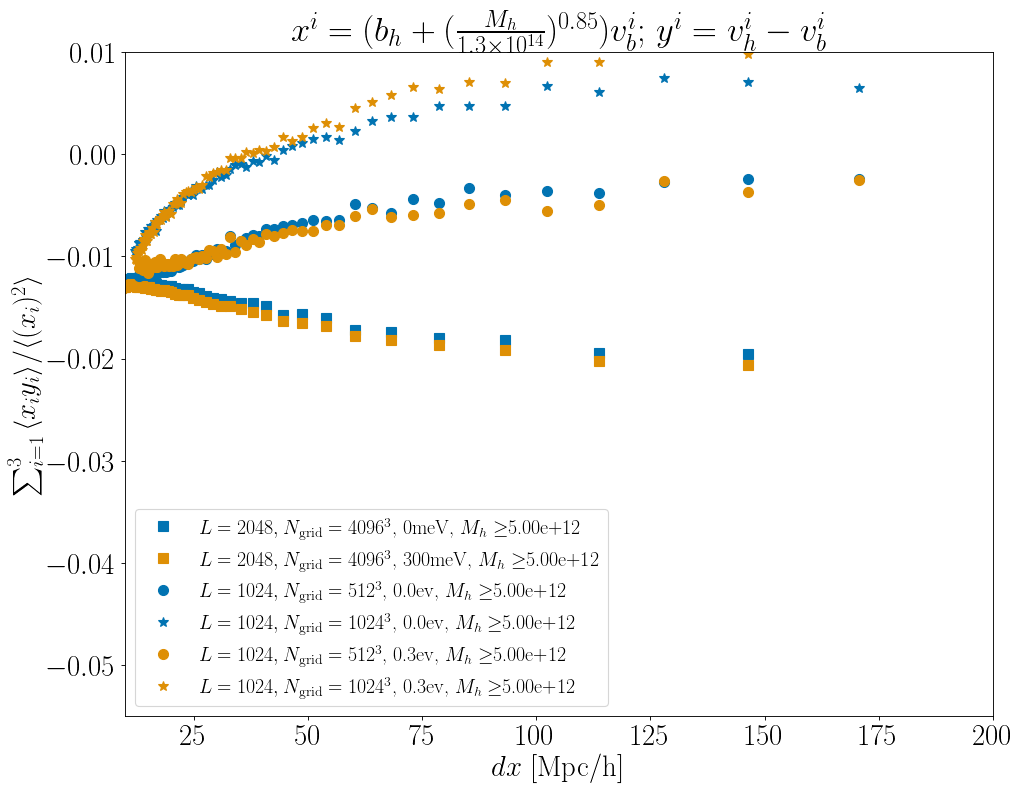

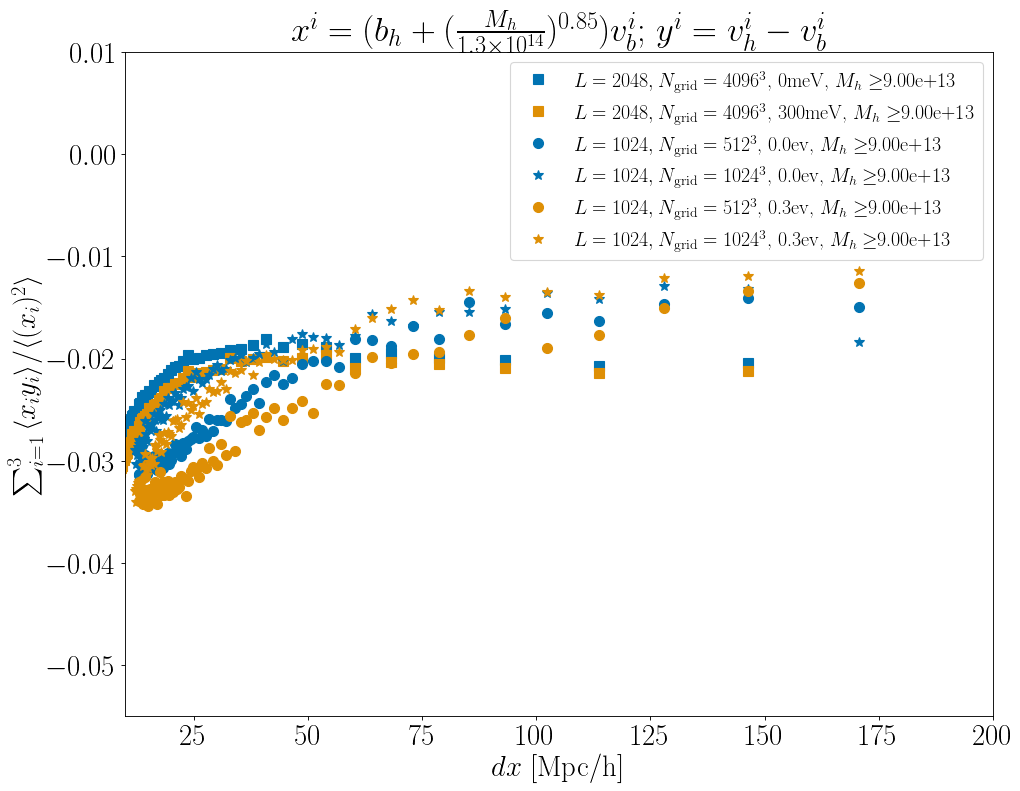

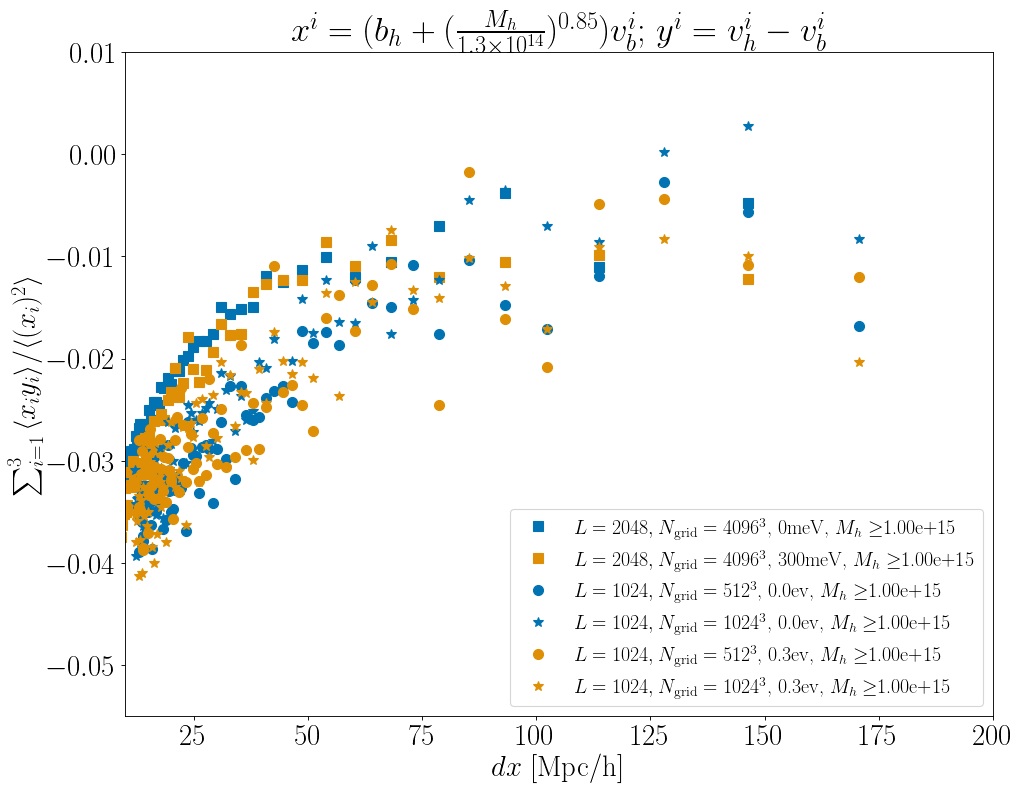

In [44]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
# for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# for sim in ['0.0ev','0.6ev']:
sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
sims_large = ["0meV", "200meV", "300meV", "60meV"]

l=0
for mass_num in [1, 10, 15]:
    figure(figsize=(14, 11), dpi=80)
        #########
    l=0
    for sim in ['0meV', '300meV']:
        df = df_huge[mass_num]
        Mass_cut = df_huge[mass_num]['mass_cut'][0]
        mask = df['sim']==sim
        x = df['dx'][mask]
        y = df['cor_all'][mask];
        plt.plot(x,y,"s",markersize=9,color=Colors[l], label=r"$L = 2048, N_{\rm grid}=4096^3$, "+sim[:6]+", $M_h \ge $" + f"{Mass_cut:.2e}")
        l=l+1
    l=0    
    for sim in ['0.0ev',  '0.3ev']:

        #########
        df = df_small[mass_num]
        Mass_cut = df_small[mass_num]['mass_cut'][0]
        mask = df['sim']==sim
        x = df['dx'][mask]
        y = df['cor_all'][mask];
        plt.plot(x,y,"o",markersize=9,color=Colors[l], label=r"$L = 1024, N_{\rm grid}=512^3$, "+sim[:6]+", $M_h \ge $" + f"{Mass_cut:.2e}")

        df = df_large[mass_num]
        mask = df['sim']==sim
        x = df['dx'][mask]
        y = df['cor_all'][mask];
        plt.plot(x,y,"*",markersize=9, color=Colors[l],label=r"$L = 1024, N_{\rm grid}=1024^3$, "+ sim[:6]+", $M_h \ge $" + f"{Mass_cut:.2e}")
        
      

        l=l+1

        plt.xlabel(r"$dx$ [Mpc/h]")
        plt.ylabel(r"$\sum_{i=1}^3 {\langle x_i y_i \rangle}/{ \langle (x_i)^2 \rangle}  $")
        plt.title(r"$x^i = (b_h+(\frac{M_h}{1.3 \times 10^{14}})^{0.85}) v_b^i$;  $y^i = v_h^i - v_b^i$")
        # plt.yscale('symlog')
        # plt.xscale('log')
        plt.xlim(10,200)
        plt.ylim(-0.055,0.01)
        plt.legend(fontsize=18)
    # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

# Difference between $\langle x y \rangle/ \langle x_i^2 \rangle$

IndexError: list index out of range

<Figure size 1120x880 with 0 Axes>

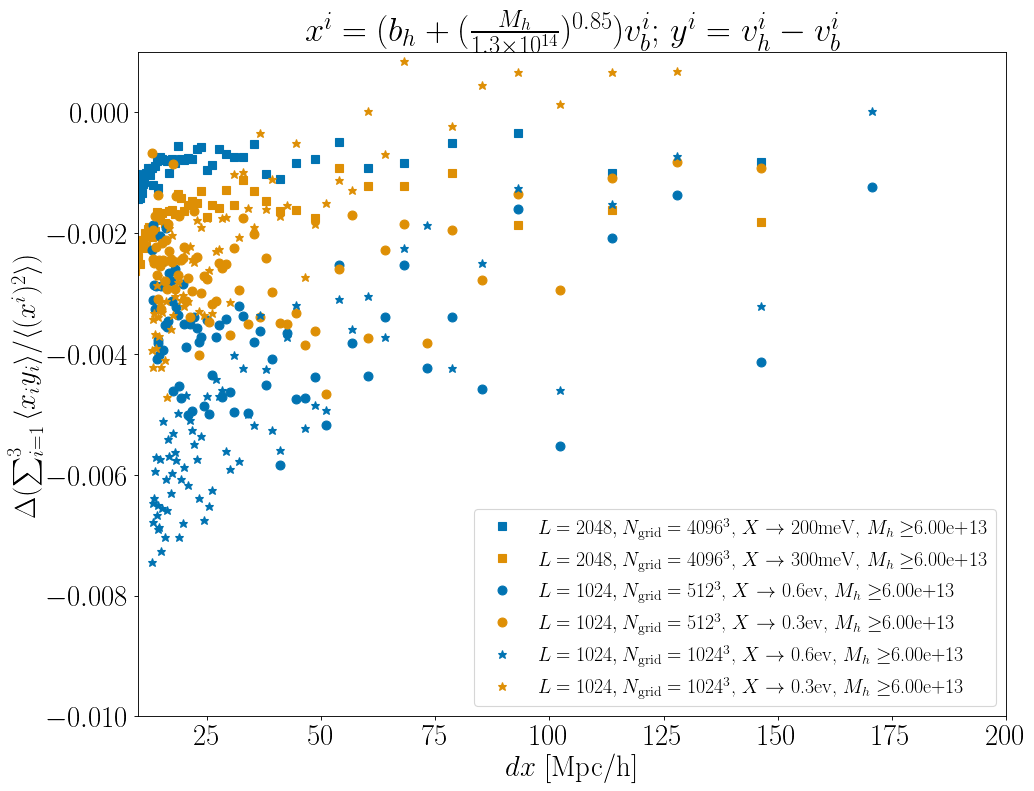

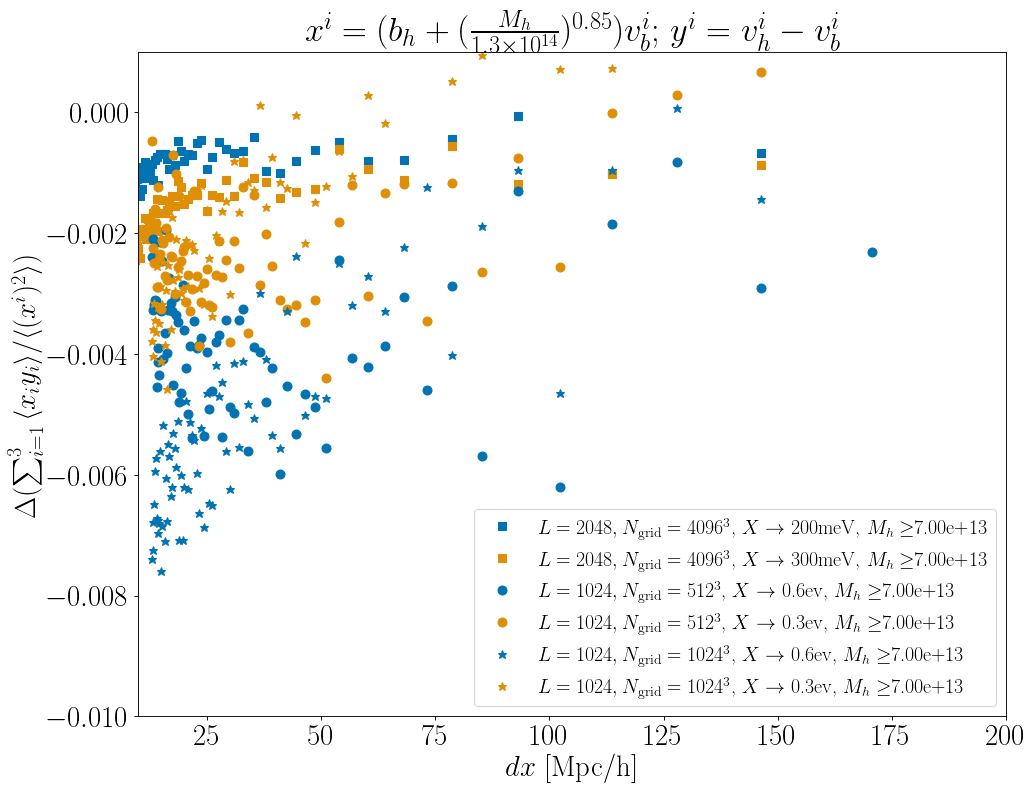

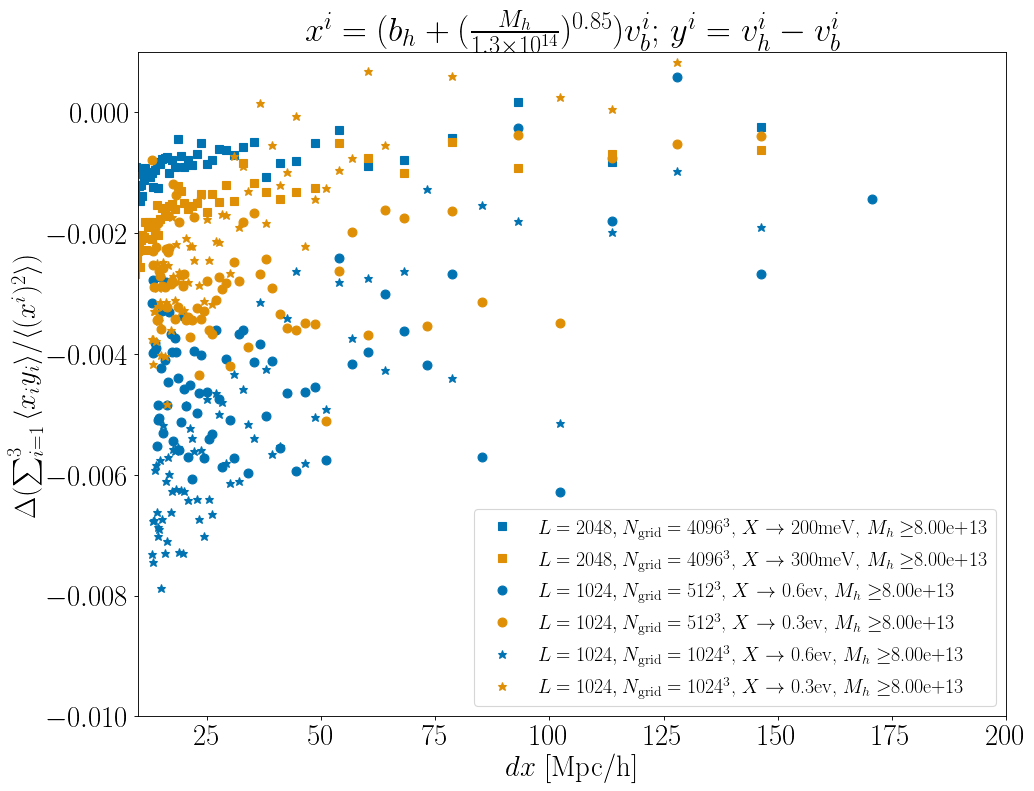

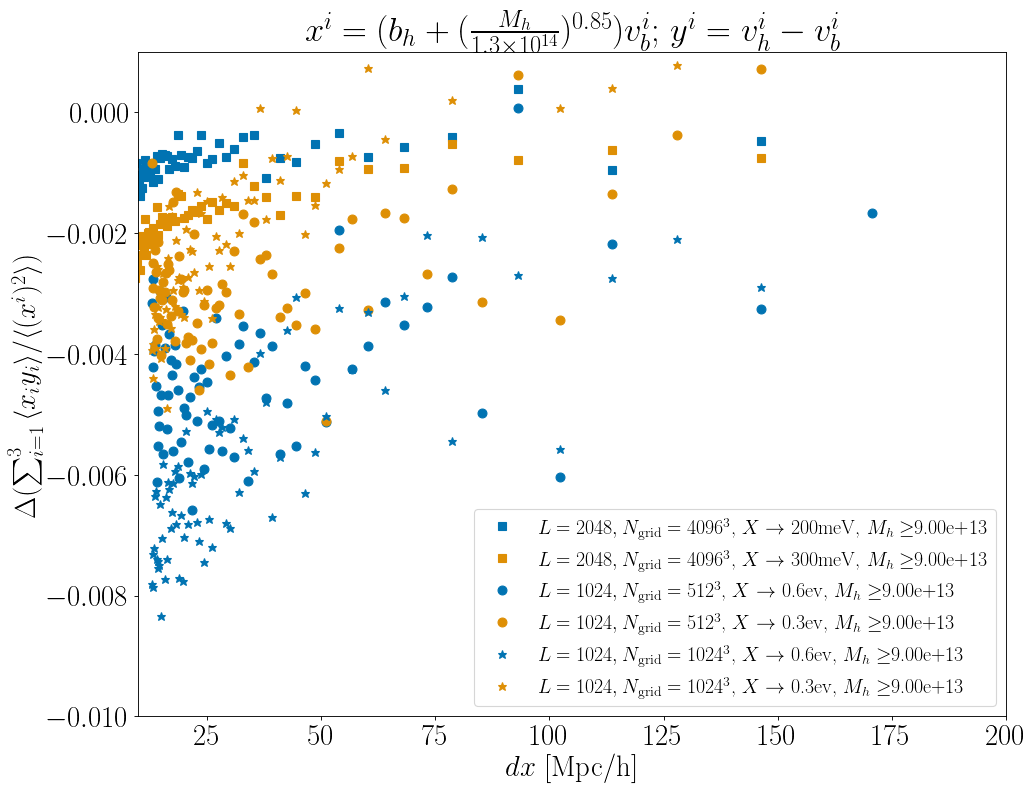

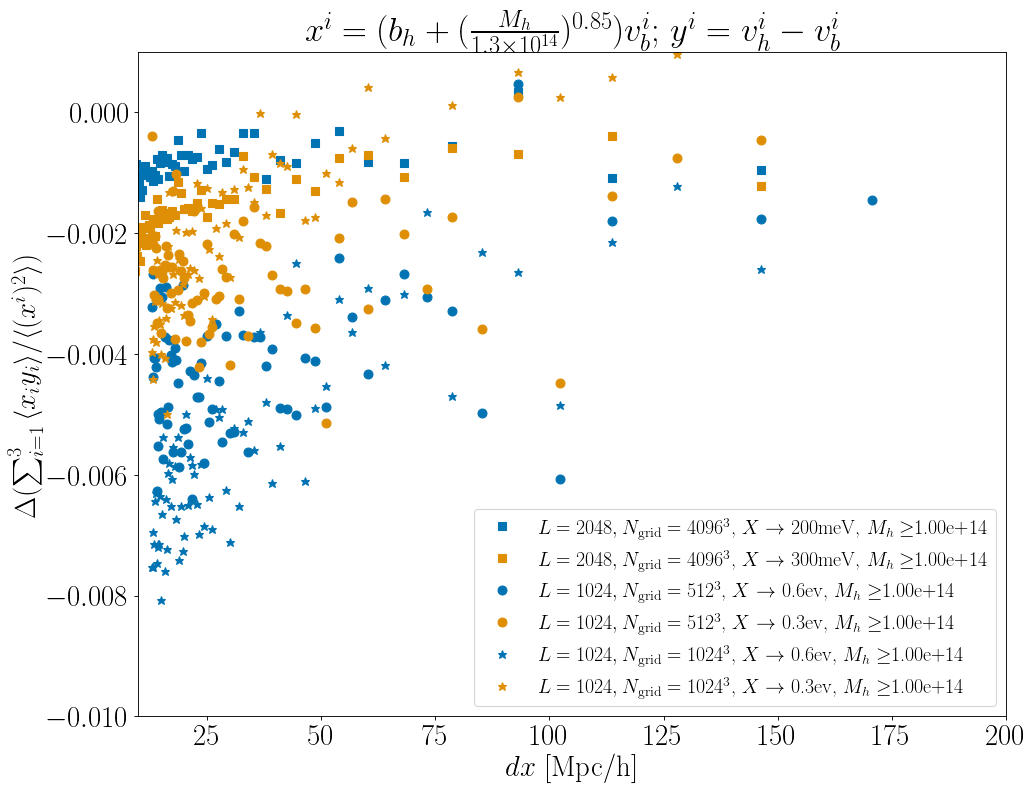

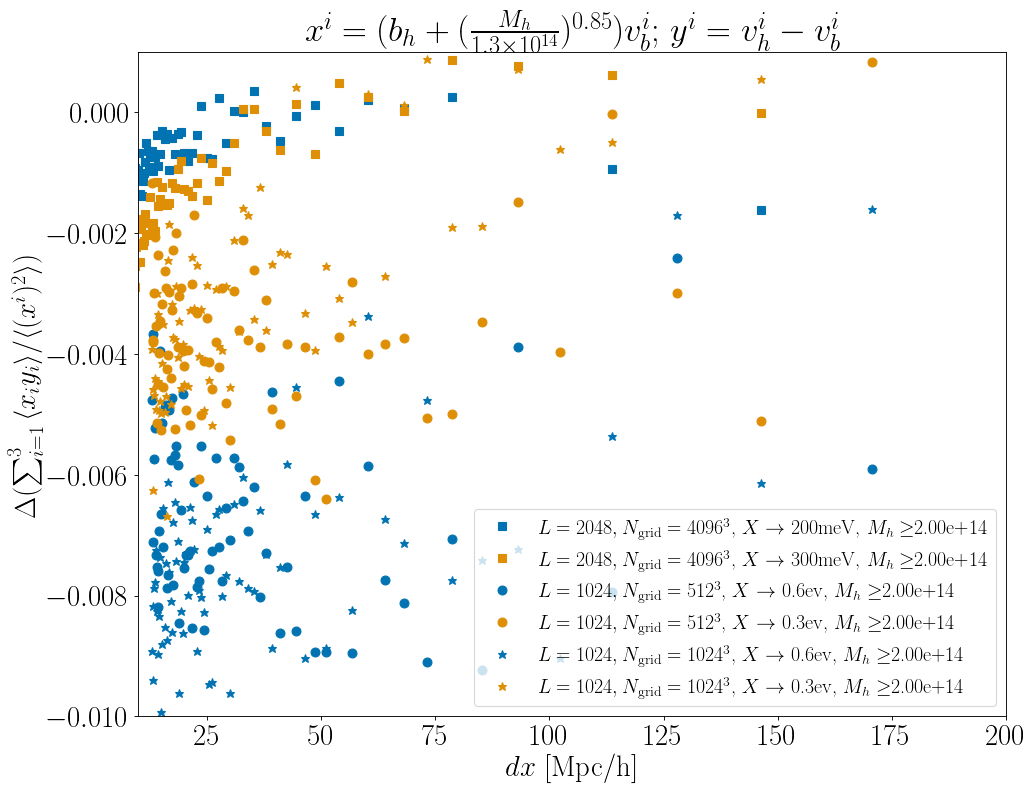

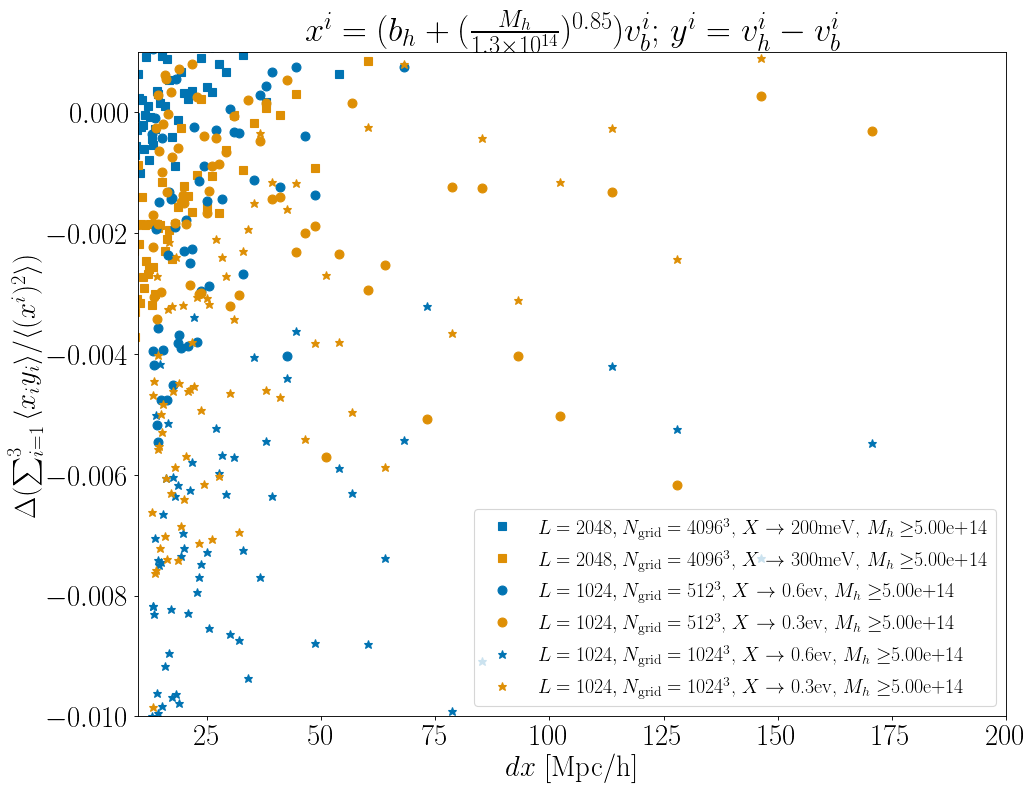

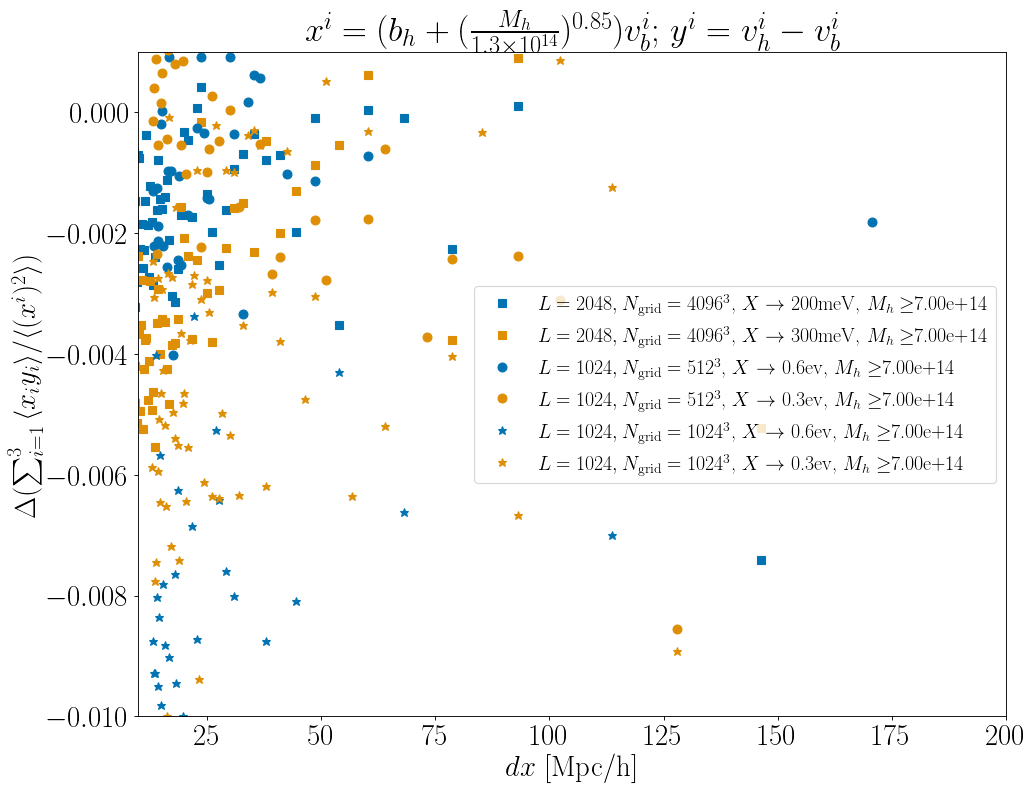

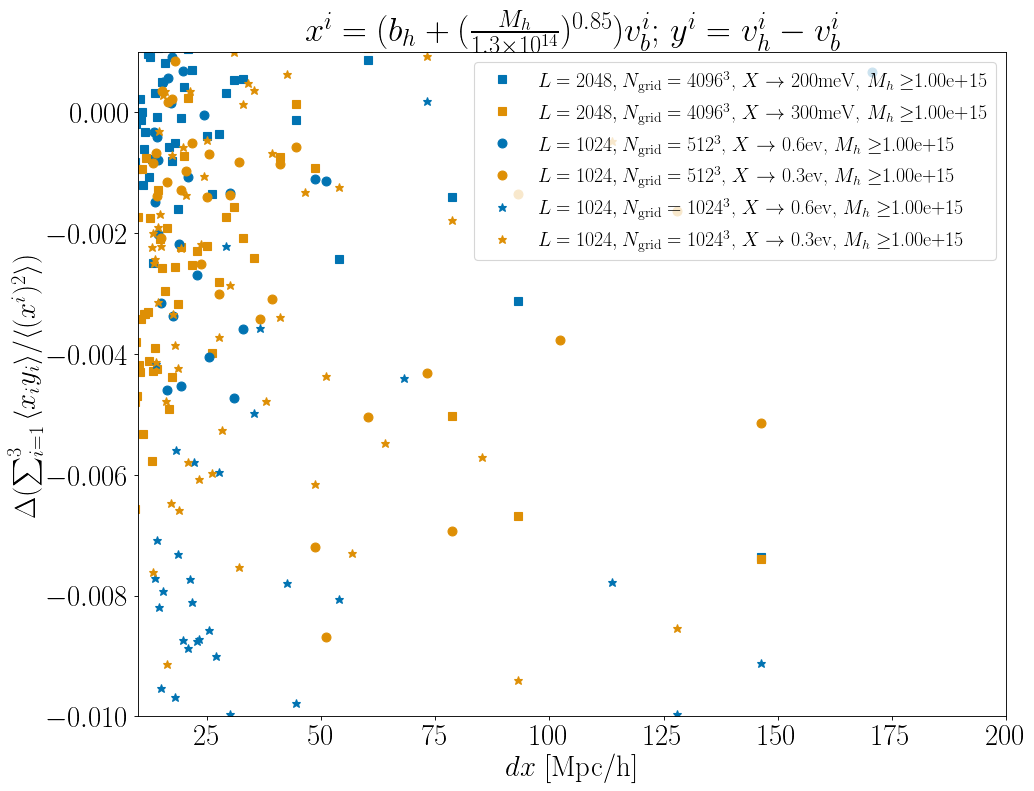

<Figure size 1120x880 with 0 Axes>

In [48]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
# for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# for sim in ['0.0ev','0.6ev']:
sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
sims_large = [ "200meV", "300meV", "60meV"]
ms = 8

for mass_num in [7,8,9,10,11,12,13,14,15,16,17]:
    l=0
    figure(figsize=(14, 11), dpi=80)
    for sim in ["200meV", "300meV"]:
        Mass_cut = df_huge[mass_num]['mass_cut'][0]
        df = df_huge[mass_num]
        mask_base = df['sim']=='0meV'
        mask = df['sim']== sim
        x = np.array(df['dx'][mask])
        x_b =np.array(df['dx'][mask_base])
        y_b = np.array(df['cor_all'][mask_base]);
        y =np.array( df['cor_all'][mask]);
        plt.plot(x_b[:num],y[:num]-y_b[:num], "s", markersize=ms, color=Colors[l], label=r"$L = 2048, N_{\rm grid}=4096^3$, $X \to$ "+sim[:6]+", $M_h \ge $" + f"{Mass_cut:.2e}")

        
        l=l+1
    l=0    
    # for sim in ['0.0ev',  '0.6ev','0.3ev', '0.15ev']:
    for sim in ['0.6ev','0.3ev']: #, '0.15ev']:

        Mass_cut = df_small[mass_num]['mass_cut'][0]

        #########
        num = 79
        df = df_small[mass_num]
        mask_base = df['sim']=='0.0ev'
        mask = df['sim']== sim
        x = np.array(df['dx'][mask])
        x_b =np.array(df['dx'][mask_base])
        y_b = np.array(df['cor_all'][mask_base]);
        y =np.array( df['cor_all'][mask]);
        plt.plot(x_b[:num],y[:num]-y_b[:num],"o", markersize=ms, color=Colors[l], label=r"$L = 1024, N_{\rm grid}=512^3$, $X \to$ "+sim+", $M_h \ge $" + f"{Mass_cut:.2e}")
        #######
        l=l+1
    l=0    
    # for sim in ['0.0ev',  '0.6ev','0.3ev', '0.15ev']:
    for sim in ['0.6ev','0.3ev']: #, '0.15ev']:   
        num = 79
        df = df_large[mass_num]
        mask_base = df['sim']=='0.0ev'
        mask = df['sim']== sim
        x = np.array(df['dx'][mask])
        x_b =np.array(df['dx'][mask_base])
        y_b = np.array(df['cor_all'][mask_base]);
        y =np.array( df['cor_all'][mask]);
        plt.plot(x_b[:num],y[:num]-y_b[:num],"*", markersize=ms, color=Colors[l], label=r"$L = 1024, N_{\rm grid}=1024^3$, $X \to$ "+sim+", $M_h \ge $" + f"{Mass_cut:.2e}")

  
        l=l+1

        plt.xlabel(r"$dx$ [Mpc/h]")
        plt.ylabel(r"$\Delta (\sum_{i=1}^3 {\langle x_i y_i \rangle}/{ \langle (x^i)^2 \rangle})  $")
        plt.title(r"$x^i = (b_h+(\frac{M_h}{1.3 \times 10^{14}})^{0.85}) v_b^i$;  $y^i = v_h^i - v_b^i$")
        # plt.yscale('symlog')
        # plt.xscale('log')
        plt.xlim(10,200)
        plt.ylim(-0.01,0.001)
        plt.legend(fontsize=18)
        # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

<Figure size 1120x880 with 0 Axes>

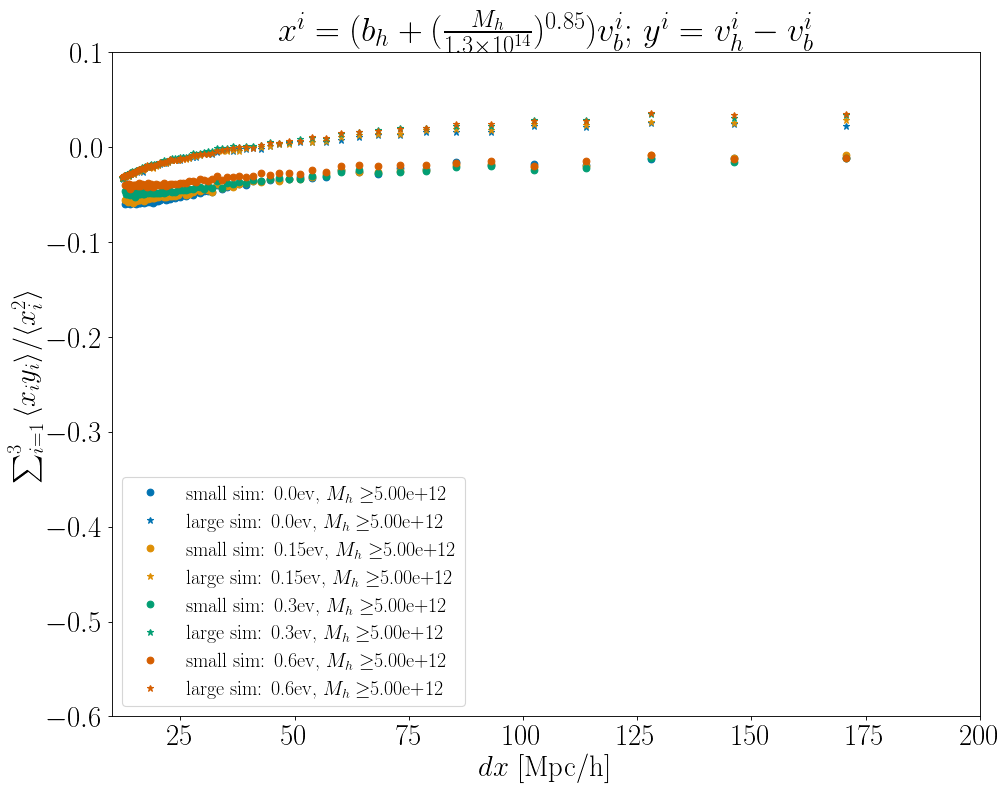

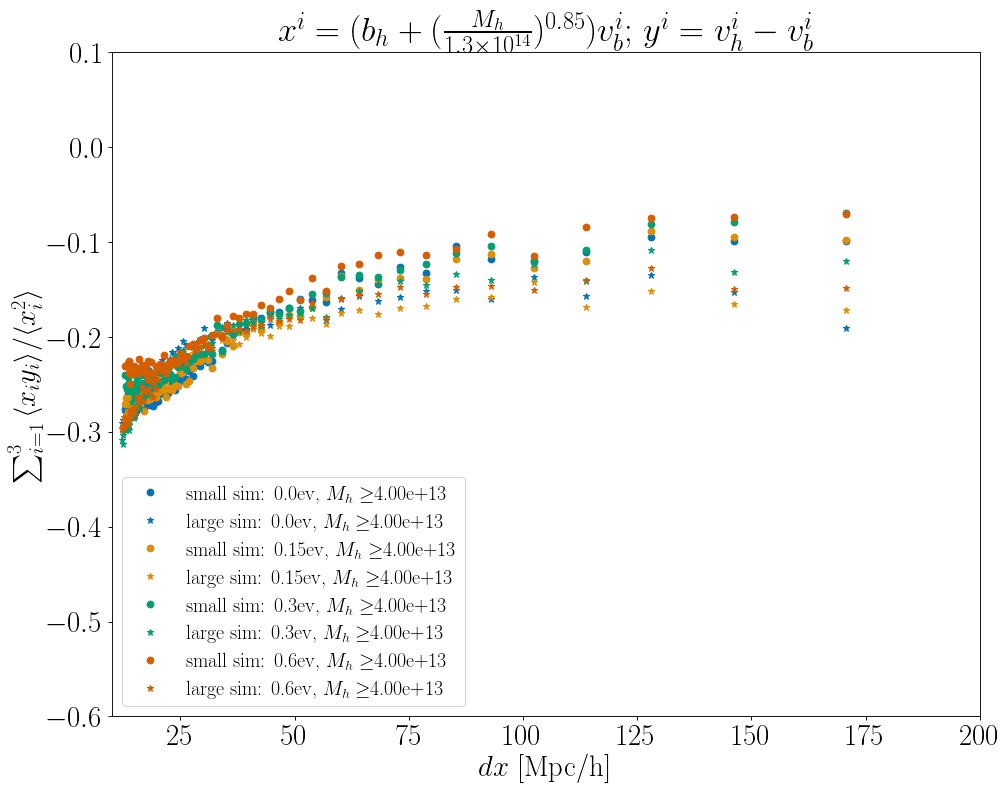

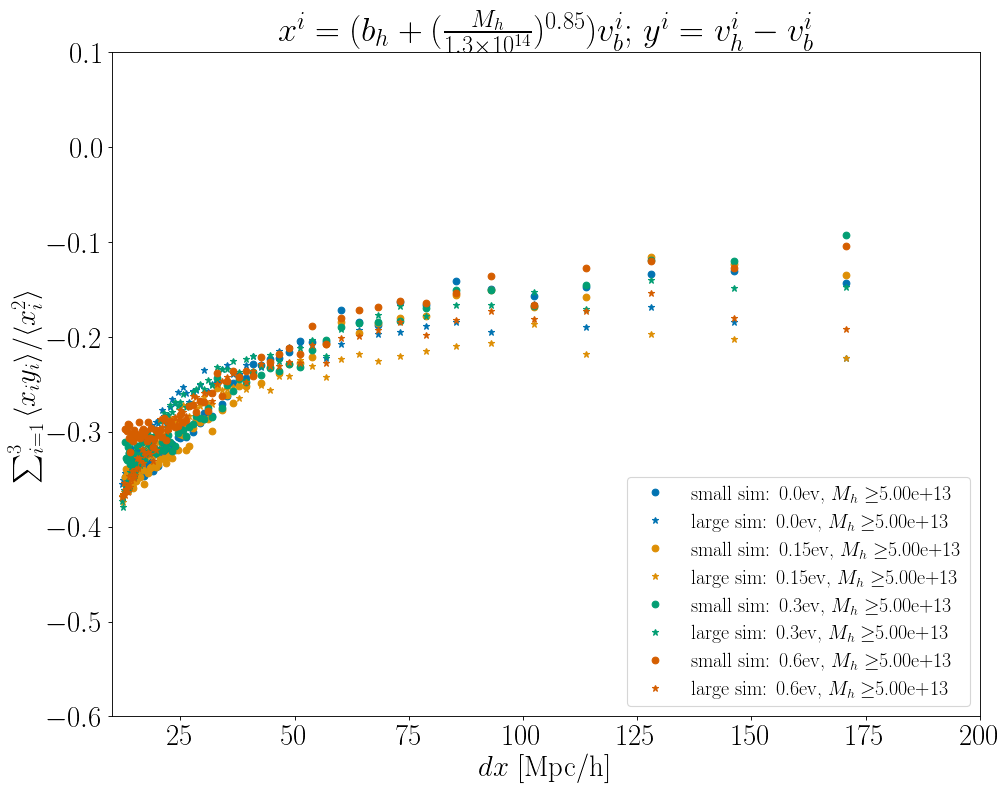

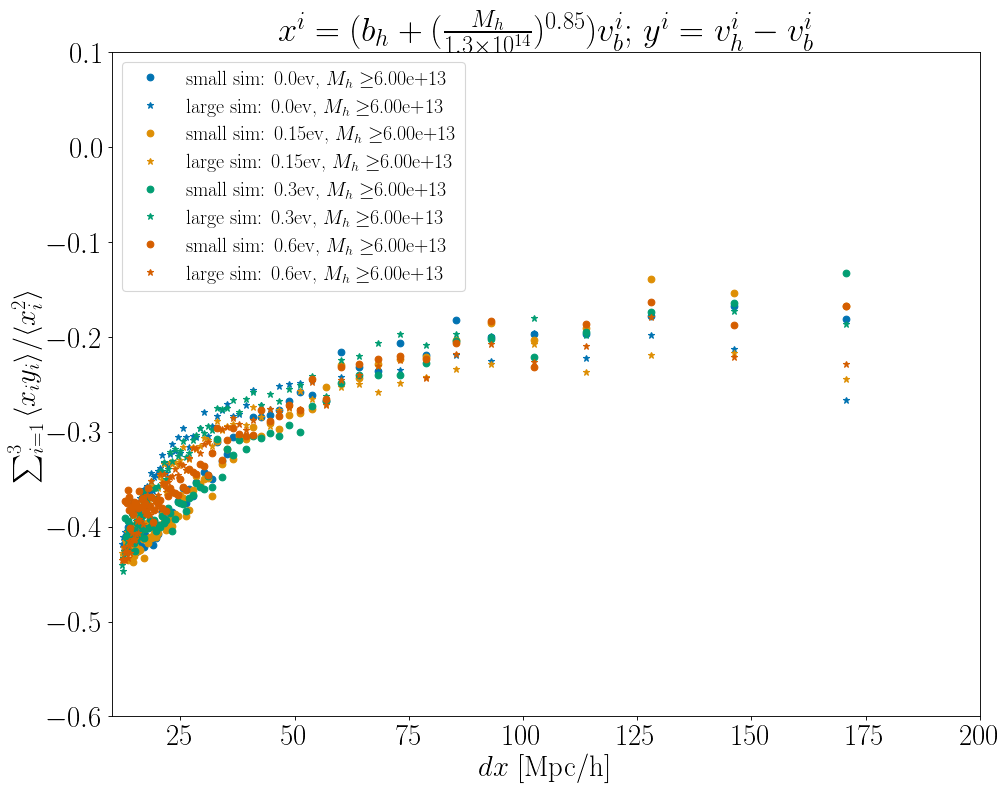

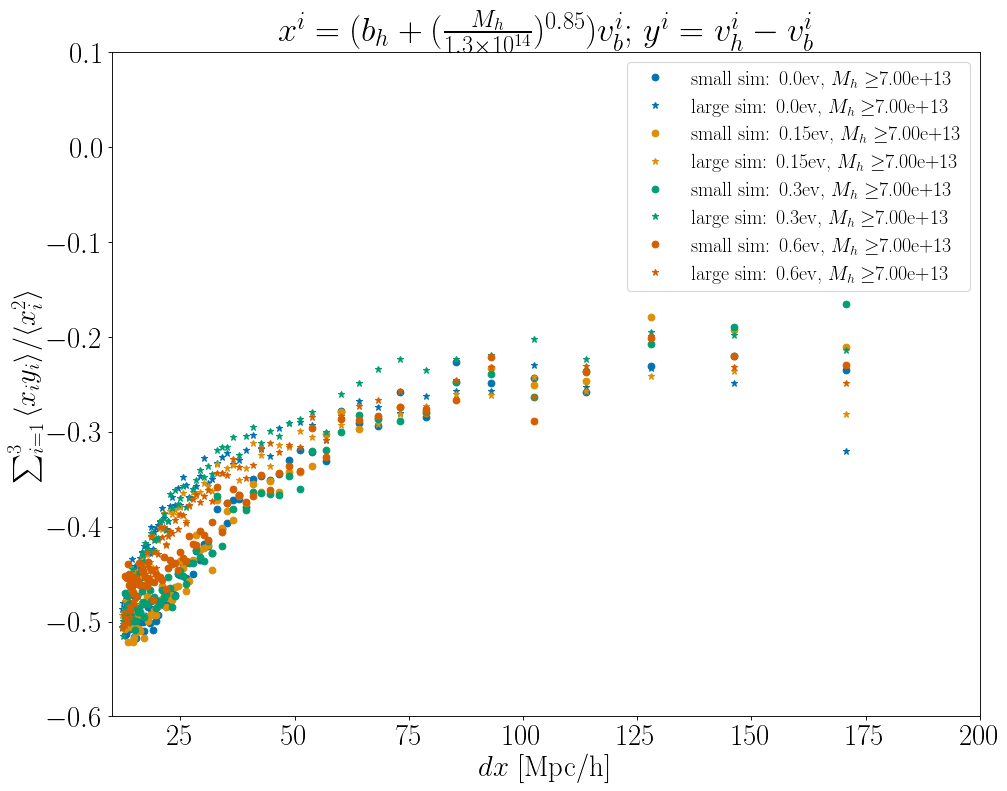

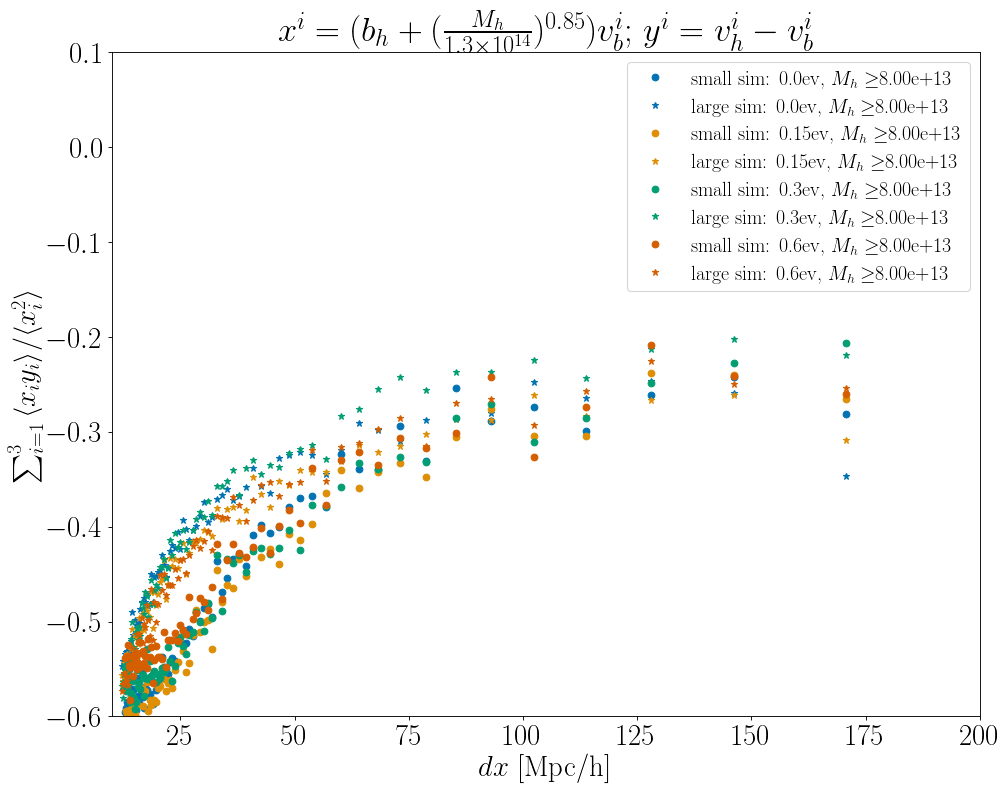

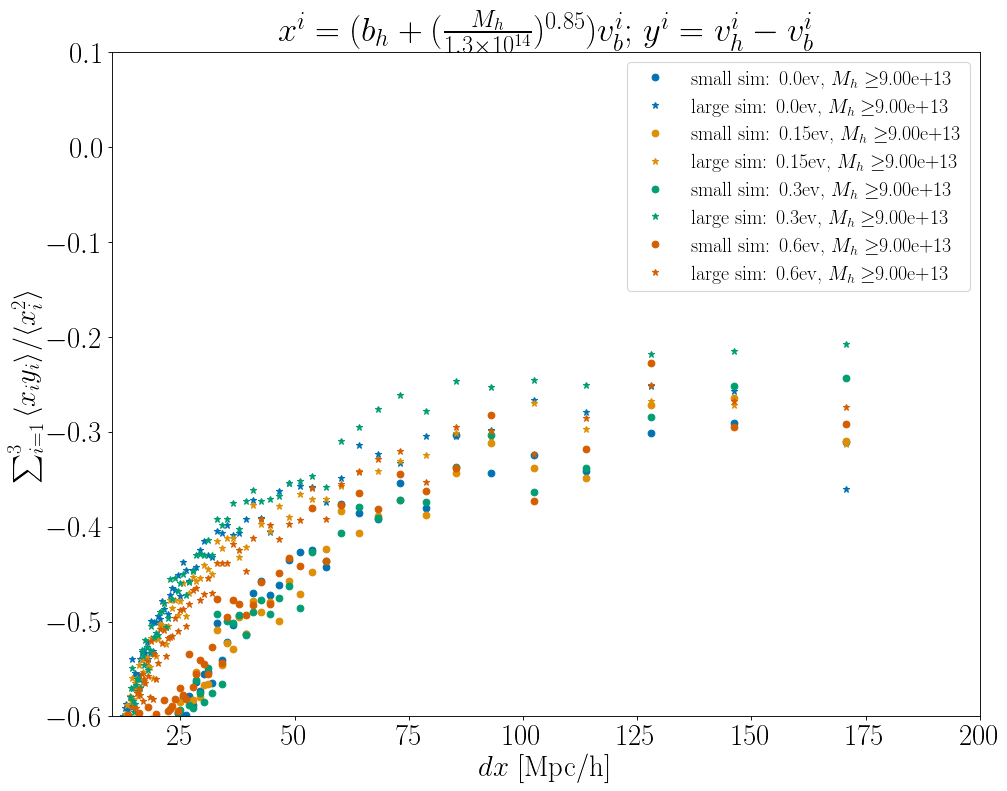

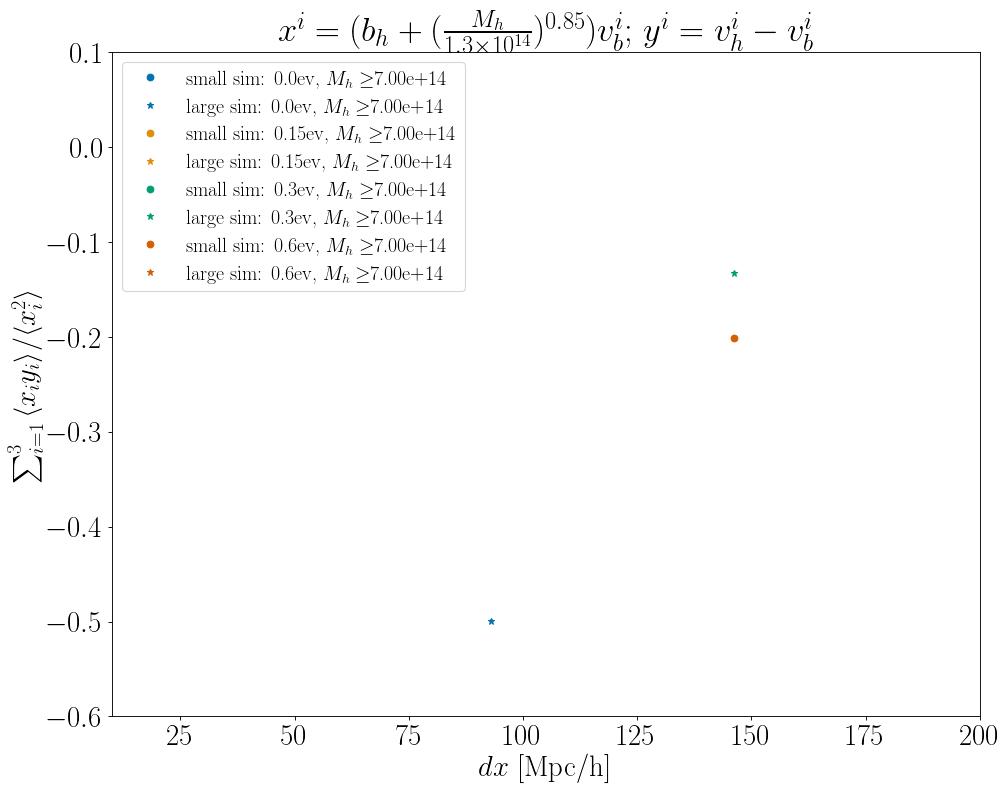

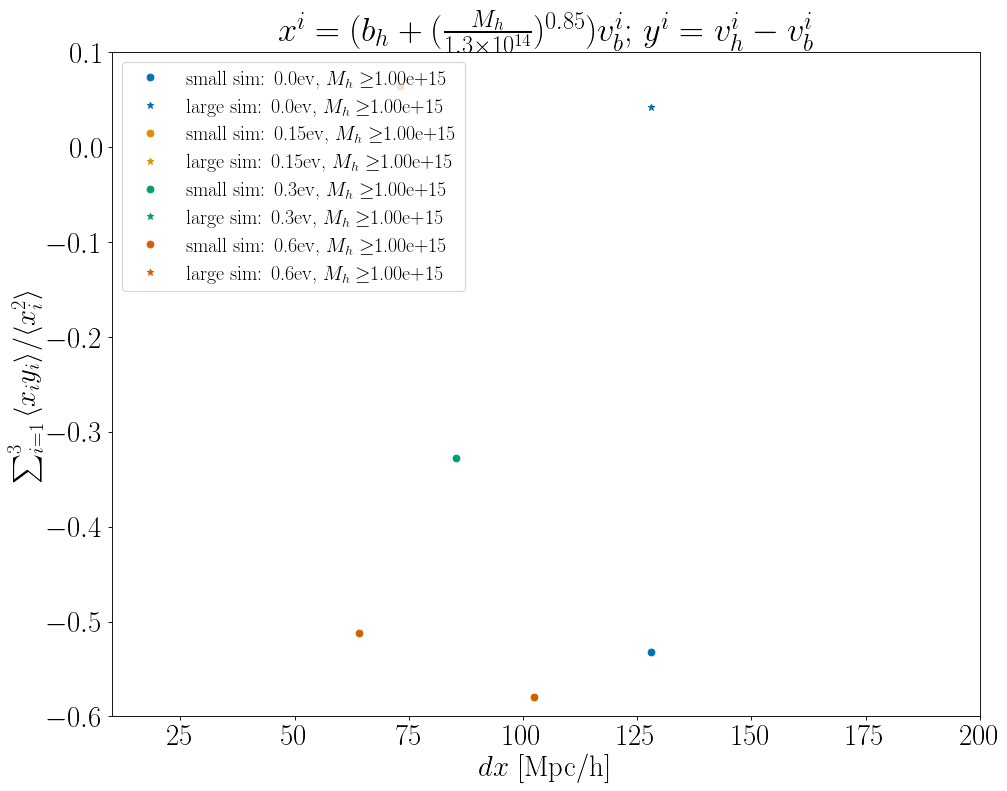

In [30]:
# ## Halo model:
# model = 'sheth01'
# z = 0.0
# mdef = '200m'
# ###FIG###
# c=26
# plt.rc('text', usetex=True)
# font = {'family' : 'normal',
#         'weight' : 'bold',
#         'size'   : c}
# matplotlib.rc('font', **font)
# figure(figsize=(14, 11), dpi=80)
# # for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# # for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# # for sim in ['0.0ev','0.6ev']:
# sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
# sims_huge = ["0meV", "200meV", "300meV", "60meV"]


# for mass_num in [1,5, 6, 7, 8, 9, 10, 14, 15]:
#     figure(figsize=(14, 11), dpi=80)
#     l=0
#     for sim in ['0.0ev', '0.15ev', '0.3ev', '0.6ev']:
#     # for sim in ['0.0ev', '0.6ev']:
#         Mass_cut = df_small[mass_num]['mass_cut'][0]

#         #########
#         df = df_small[mass_num]
#         mask = df['sim']==sim
#         x = df['dx'][mask]
#         y = df['cor_all_vel'][mask];
#         plt.plot(x,y,"o",color=Colors[l], label="small sim: "+sim[:6]+", $M_h \ge $" + f"{Mass_cut:.2e}")

#         df = df_large[mass_num]
#         mask = df['sim']==sim
#         x = df['dx'][mask]
#         y = df['cor_all_vel'][mask];
#         plt.plot(x,y,"*", color=Colors[l],label="large sim: "+ sim[:6]+", $M_h \ge $" + f"{Mass_cut:.2e}")

#         # df = df_huge
#         # mask = (df['sim']==sims_huge[l])
#         # x = df['dx'][mask]
#         # y = df['cor_all_2'][mask];
#         # plt.plot(x,y,"v", color=Colors[l],label="huge sim: "+ sims_huge[l][:6])      
#         l=l+1

#         plt.xlabel(r"$dx$ [Mpc/h]")
#         plt.ylabel(r"$\sum_{i=1}^3 {\langle x_i y_i \rangle}/{ \langle x_i^2 \rangle}  $")
#         plt.title(r"$x^i = (b_h+(\frac{M_h}{1.3 \times 10^{14}})^{0.85}) v_b^i$;  $y^i = v_h^i - v_b^i$")
#         # plt.yscale('symlog')
#         # plt.xscale('log')
#         plt.xlim(10,200)
#         plt.ylim(-0.6,0.1)
#         plt.legend(fontsize=18)
#         # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

# Difference between $\langle x y \rangle/ \langle v_i^2 \rangle$

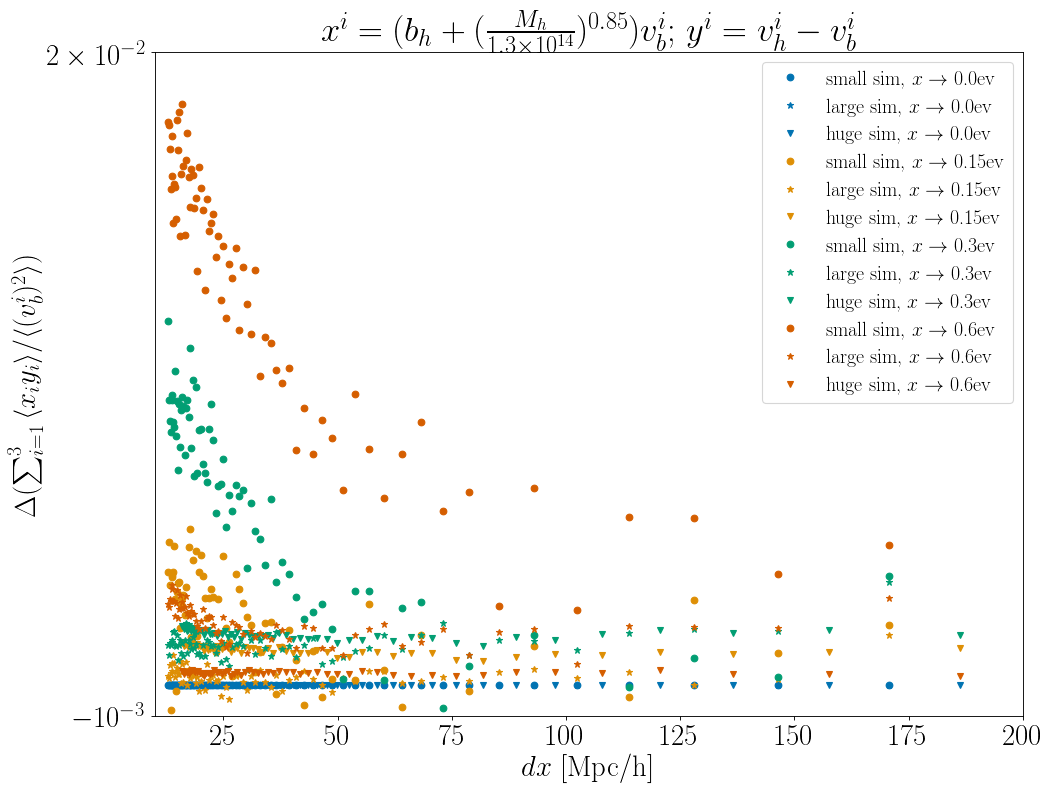

In [6]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
# for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# for sim in ['0.0ev','0.6ev']:
sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
sims_large = ["0meV", "200meV", "300meV", "60meV"]

l=0
for sim in sims:

    #########
    num = 79
    df = df_small
    mask_base = df['sim']=='0.0ev'
    mask = df['sim']== sim
    x = np.array(df['dx'][mask])
    x_b =np.array(df['dx'][mask_base])
    y_b = np.array(df['cor_all'][mask_base]);
    y =np.array( df['cor_all'][mask]);
    plt.plot(x_b[:num],y[:num]-y_b[:num],"o", color=Colors[l], label=r"small sim, $x \to$ "+sim)
    #######
    df = df_large
    mask_base = df['sim']=='0.0ev'
    mask = df['sim']== sim
    x = np.array(df['dx'][mask])
    x_b =np.array(df['dx'][mask_base])
    y_b = np.array(df['cor_all'][mask_base]);
    y =np.array( df['cor_all'][mask]);
    plt.plot(x_b[:num],y[:num]-y_b[:num],"*", color=Colors[l], label=r"large sim, $x \to$ "+sim)

    df = df_huge
    mask_base = df['sim']=='0meV'
    mask = (df['sim']==sims_huge[l])
    x = np.array(df['dx'][mask])
    x_b =np.array(df['dx'][mask_base])
    y_b = np.array(df['cor_all'][mask_base]);
    y =np.array( df['cor_all'][mask]);
    plt.plot(x_b[:num],y[:num]-y_b[:num], "v", color=Colors[l], label=r"huge sim, $x \to$ "+sim)
    
    l=l+1

    plt.xlabel(r"$dx$ [Mpc/h]")
    plt.ylabel(r"$\Delta (\sum_{i=1}^3 {\langle x_i y_i \rangle}/{ \langle (v_b^i)^2 \rangle})  $")
    plt.title(r"$x^i = (b_h+(\frac{M_h}{1.3 \times 10^{14}})^{0.85}) v_b^i$;  $y^i = v_h^i - v_b^i$")
    plt.yscale('symlog')
    # plt.xscale('log')
    plt.xlim(10,200)
    plt.ylim(-0.001,0.02)
    plt.legend(fontsize=18)
    # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

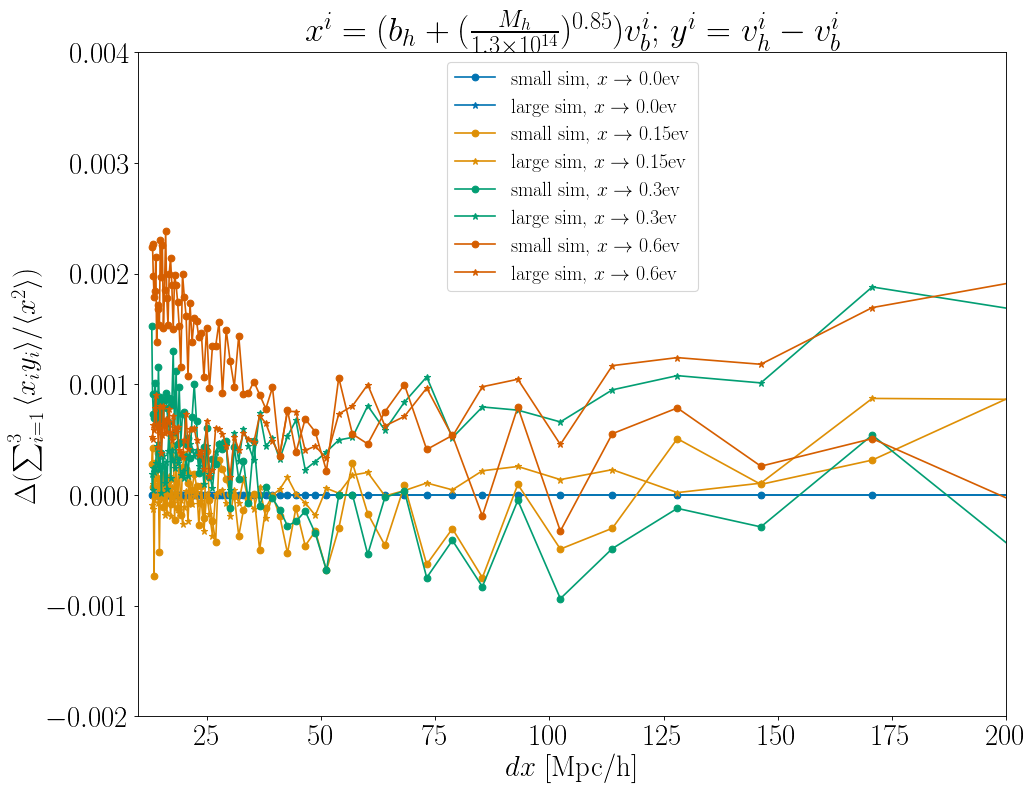

In [14]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
# for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# for sim in ['0.0ev','0.6ev']:
sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
sims_large = ["0meV", "200meV", "300meV", "60meV"]

l=0
for sim in sims:

    #########
    num = 79
    df = df_small
    mask_base = df['sim']=='0.0ev'
    mask = df['sim']== sim
    x = np.array(df['dx'][mask])
    x_b =np.array(df['dx'][mask_base])
    y_b = np.array(df['cor_all_2'][mask_base]);
    y =np.array( df['cor_all_2'][mask]);
    plt.plot(x_b[:num],y[:num]-y_b[:num],"o-",  color=Colors[l], label=r"small sim, $x \to$ "+sim)
    #######
    df = df_large
    mask_base = df['sim']=='0.0ev'
    mask = df['sim']== sim
    x = np.array(df['dx'][mask])
    x_b =np.array(df['dx'][mask_base])
    y_b = np.array(df['cor_all_2'][mask_base]);
    y =np.array( df['cor_all_2'][mask]);
    plt.plot(x_b[:num],y[:num]-y_b[:num],"*-", color=Colors[l], label=r"large sim, $x \to$ "+sim)

    # df = df_huge
    # mask_base = df['sim']=='0meV'
    # mask = (df['sim']==sims_huge[l])
    # x = np.array(df['dx'][mask])
    # x_b =np.array(df['dx'][mask_base])
    # y_b = np.array(df['cor_all_2'][mask_base]);
    # y =np.array( df['cor_all_2'][mask]);
    # plt.plot(x_b[:num],y[:num]-y_b[:num], "o-", color=Colors[l], label=r"huge sim, $x \to$ "+sims_huge[l])
    
    l=l+1

    plt.xlabel(r"$dx$ [Mpc/h]")
    plt.ylabel(r"$\Delta (\sum_{i=1}^3 {\langle x_i y_i \rangle}/{ \langle x^2 \rangle})  $")
    plt.title(r"$x^i = (b_h+(\frac{M_h}{1.3 \times 10^{14}})^{0.85}) v_b^i$;  $y^i = v_h^i - v_b^i$")
    # plt.yscale('symlog')
    # plt.xscale('log')
    plt.xlim(10,200)
    plt.ylim(-0.002,0.004)
    plt.legend(fontsize=18)
    # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

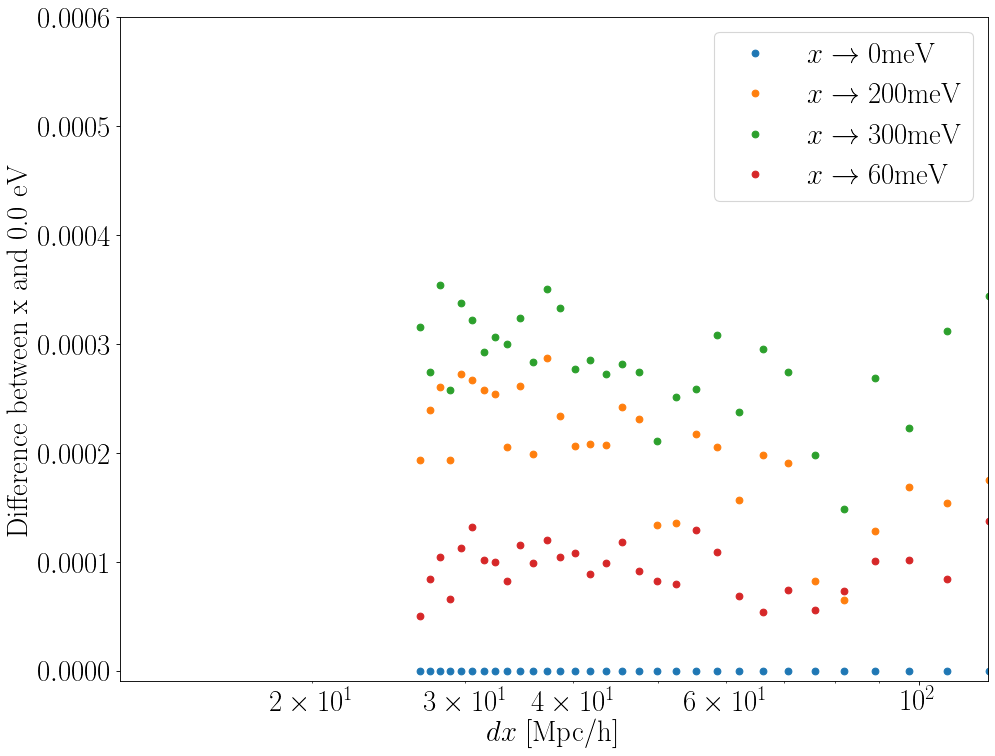

In [66]:
# ## Halo model:
# model = 'sheth01'
# z = 0.0
# mdef = '200m'
# ###FIG###
# c=26
# plt.rc('text', usetex=True)
# font = {'family' : 'normal',
#         'weight' : 'bold',
#         'size'   : c}
# matplotlib.rc('font', **font)
# figure(figsize=(14, 11), dpi=80)
# # for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# for sim in sims:


#     #########
#     mask_base = df['sim']=='0meV'
#     mask = df['sim']== sim

#     x = np.array(df['dx'][mask])
#     x_b =np.array(df['dx'][mask_base])

#     y_b = np.array(df['cor_all_2'][mask_base]);
#     y =np.array( df['cor_all_2'][mask]);
    
#     num=39
#     plt.plot(x_b[:num],y[:num]-y_b[:num],"o", label=r"$x \to$ "+sim)
#     # plt.plot(x[:74],y[:74],"o")

#     plt.xlabel(r"$dx$ [Mpc/h]")
#     plt.ylabel(r"Difference between x and 0.0 eV")
#     # plt.title(r"All components of $v_h$ and $v_b$")
#     # plt.yscale('symlog')
#     plt.xscale('log')
#     plt.xlim(12,120)
#     plt.ylim(-1.e-5,6.e-4)
#     plt.legend()
#     # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

In [55]:
sims

['0meV', '200meV', '300meV', '60meV']

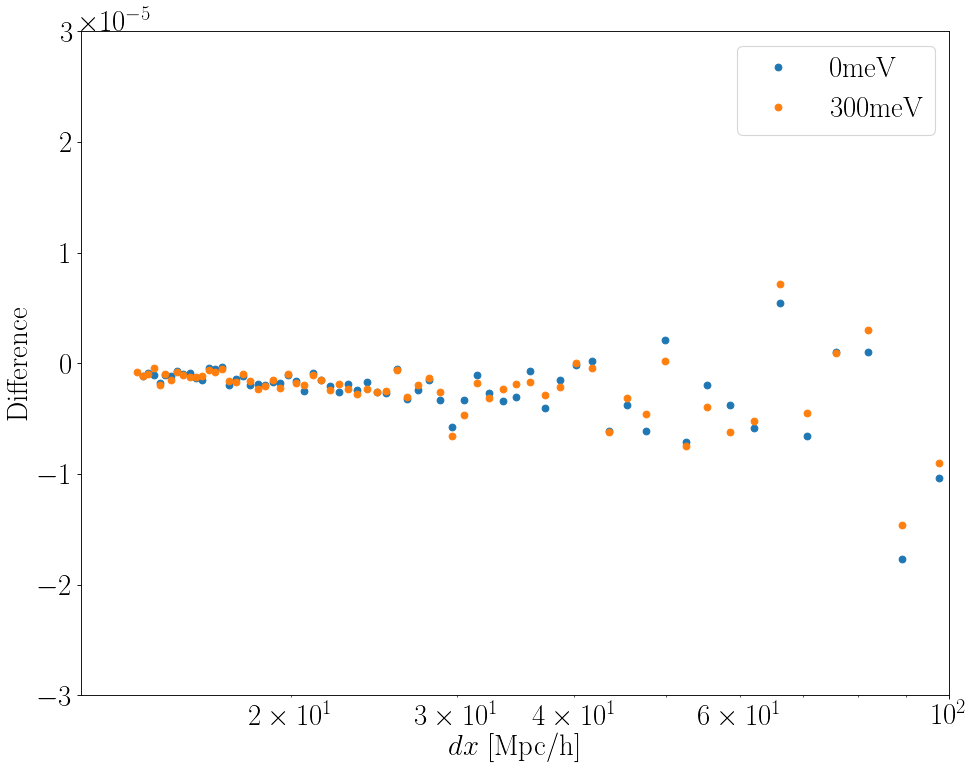

In [18]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
# for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
for sim in ['0meV','300meV']:


    #########
    mask = df['sim']==sim
    x = df['dx'][mask]
    y = df['cor_all'][mask];
    plt.plot(x,y,"o",label=sim[:6])

    plt.xlabel(r"$dx$ [Mpc/h]")
    plt.ylabel(r"Difference")
    # plt.title(r"All components of $v_h$ and $v_b$")
    # plt.yscale('symlog')
    plt.xscale('log')
    plt.xlim(12,100)
    plt.ylim(-3.e-5,3.e-5)
    plt.legend()
    # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

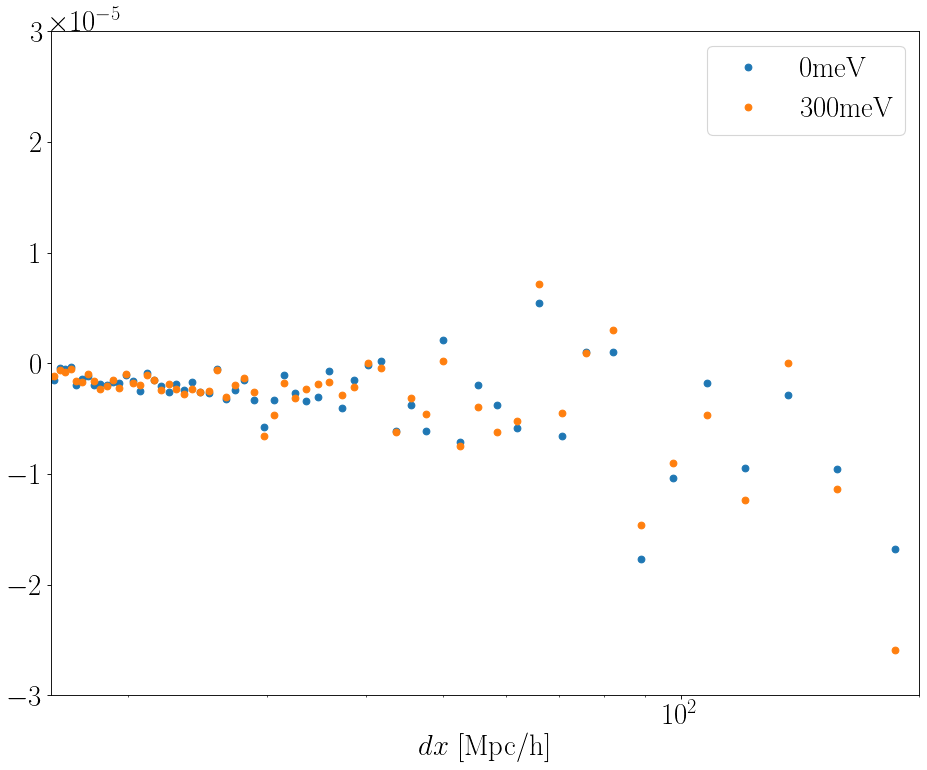

In [10]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
# for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
for sim in ['0meV','300meV']:


    #########
    mask = df['sim']==sim
    x = df['dx'][mask]
    y = df['cor_all'][mask];
    plt.plot(x,y,"o",label=sim[:6])

    plt.xlabel(r"$dx$ [Mpc/h]")
    # plt.ylabel(r"$\sum_{j=1}^3 \sum_{i=1}^N (v_i^j - v^j_b)(b_i + \frac{M_i}{1.3 \times 10^{14}})^{0.85}v_b^j$")
    # plt.title(r"All components of $v_h$ and $v_b$")
    # plt.yscale('symlog')
    plt.xscale('log')
    plt.xlim(16,200)
    plt.ylim(-3.e-5,3.e-5)
    plt.legend()
    # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

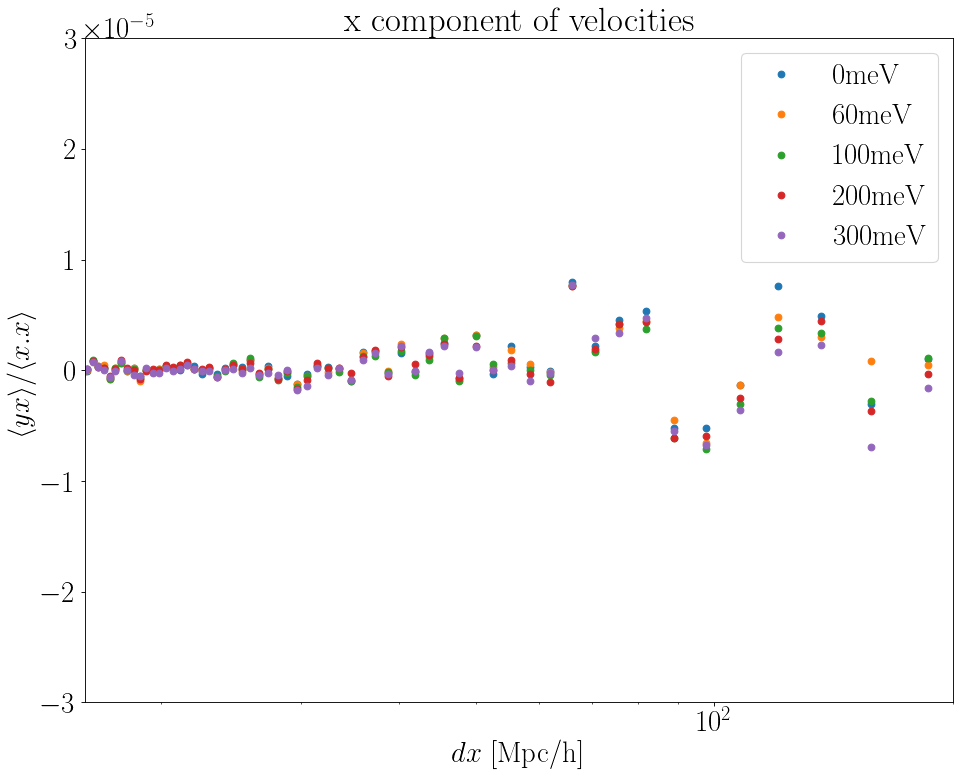

In [71]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
    

    #########
    mask = df['sim']==sim
    x = df['dx'][mask]
    y = df['cor_x'][mask];
    plt.plot(x,y,"o",label=sim[:6])

    plt.xlabel(r"$dx$ [Mpc/h]")
    plt.ylabel(r"$\langle yx \rangle/\langle x.x \rangle$")
    plt.title(r"x component of velocities")
    # plt.yscale('symlog')
    plt.xscale('log')
    plt.xlim(16,200)
    plt.ylim(-3.e-5,3.e-5)
    plt.legend()
    # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

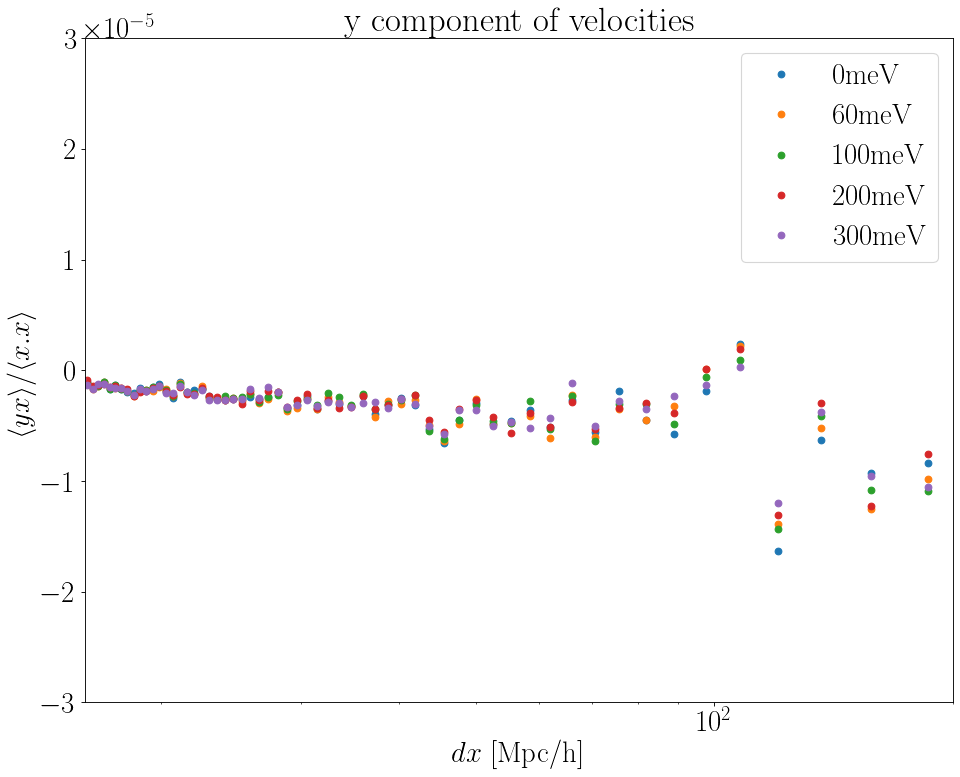

In [75]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
    

    #########
    mask = df['sim']==sim
    x = df['dx'][mask]
    y = df['cor_y'][mask];
    plt.plot(x,y,"o",label=sim[:6])

    plt.xlabel(r"$dx$ [Mpc/h]")
    plt.ylabel(r"$\langle yx \rangle/\langle x.x \rangle$")
    plt.title(r"y component of velocities")
    # plt.yscale('symlog')
    plt.xscale('log')
    plt.xlim(16,200)
    plt.ylim(-3.e-5,3.e-5)
    plt.legend()
    # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

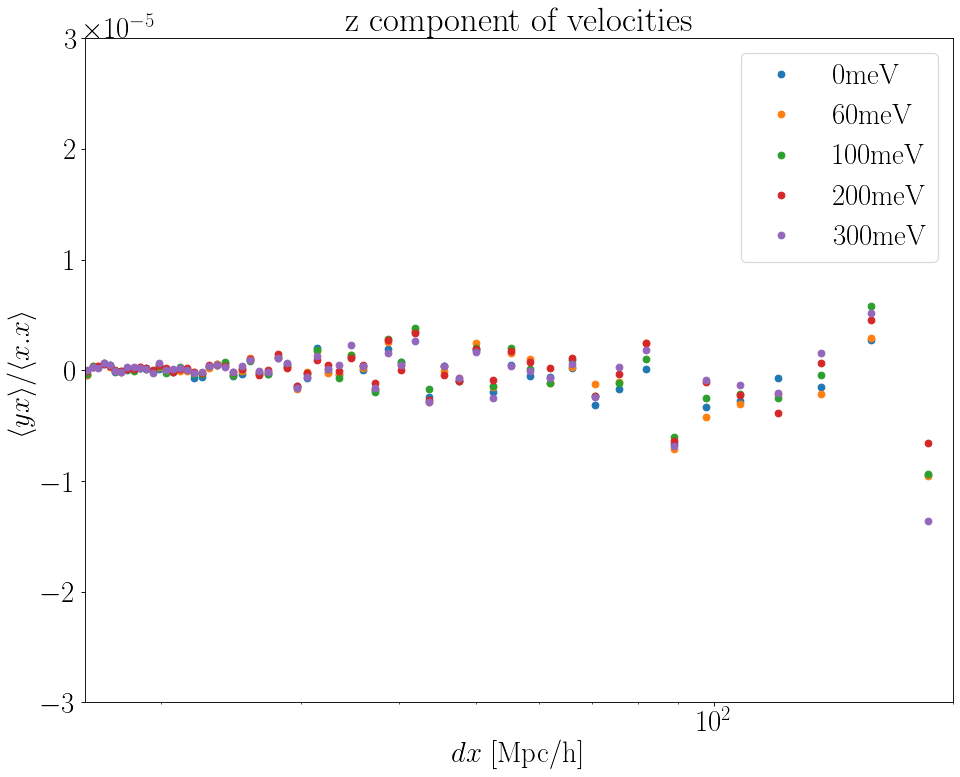

In [76]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
    

    #########
    mask = df['sim']==sim
    x = df['dx'][mask]
    y = df['cor_z'][mask];
    plt.plot(x,y,"o",label=sim[:6])

    plt.xlabel(r"$dx$ [Mpc/h]")
    plt.ylabel(r"$\langle yx \rangle/\langle x.x \rangle$")
    plt.title(r"z component of velocities")
    # plt.yscale('symlog')
    plt.xscale('log')
    plt.xlim(16,200)
    plt.ylim(-3.e-5,3.e-5)
    plt.legend()
    # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

# Difference between $\langle x y \rangle/ \langle v_i^2 \rangle$

In [15]:
# ## Halo model:
# model = 'sheth01'
# z = 0.0
# mdef = '200m'
# ###FIG###
# c=26
# plt.rc('text', usetex=True)
# font = {'family' : 'normal',
#         'weight' : 'bold',
#         'size'   : c}
# matplotlib.rc('font', **font)
# figure(figsize=(14, 11), dpi=80)
# # for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# # for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# # for sim in ['0.0ev','0.6ev']:
# sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
# sims_large = ["0meV", "200meV", "300meV", "60meV"]


# for mass_num in [1, 5, 6, 7, 8, 9, 10, 14, 15]:
#     l=0
#     figure(figsize=(14, 11), dpi=80)
#     for sim in ['0.0ev',  '0.6ev','0.3ev', '0.15ev']:
#         Mass_cut = df_small[mass_num]['mass_cut'][0]

#         #########
#         num = 79
#         df = df_small[mass_num]
#         mask_base = df['sim']=='0.0ev'
#         mask = df['sim']== sim
#         x = np.array(df['dx'][mask])
#         x_b =np.array(df['dx'][mask_base])
#         y_b = np.array(df['cor_all_vel'][mask_base]);
#         y =np.array( df['cor_all_vel'][mask]);
#         plt.plot(x_b[:num],y[:num]-y_b[:num],"o", color=Colors[l], label=r"small sim, $x \to$ "+sim+", $M_h \ge $" + f"{Mass_cut:.2e}")
#         #######
#         df = df_large[mass_num]
#         mask_base = df['sim']=='0.0ev'
#         mask = df['sim']== sim
#         x = np.array(df['dx'][mask])
#         x_b =np.array(df['dx'][mask_base])
#         y_b = np.array(df['cor_all_vel'][mask_base]);
#         y =np.array( df['cor_all_vel'][mask]);
#         plt.plot(x_b[:num],y[:num]-y_b[:num],"*", color=Colors[l], label=r"large sim, $x \to$ "+sim+", $M_h \ge $" + f"{Mass_cut:.2e}")

#         # df = df_huge
#         # mask_base = df['sim']=='0meV'
#         # mask = (df['sim']==sims_huge[l])
#         # x = np.array(df['dx'][mask])
#         # x_b =np.array(df['dx'][mask_base])
#         # y_b = np.array(df['cor_all'][mask_base]);
#         # y =np.array( df['cor_all'][mask]);
#         # plt.plot(x_b[:num],y[:num]-y_b[:num], "v", color=Colors[l], label=r"huge sim, $x \to$ "+sim)

#         l=l+1

#         plt.xlabel(r"$dx$ [Mpc/h]")
#         plt.ylabel(r"$\Delta (\sum_{i=1}^3 {\langle x_i y_i \rangle}/{ \langle (v^i)^2 \rangle})  $")
#         plt.title(r"$x^i = (b_h+(\frac{M_h}{1.3 \times 10^{14}})^{0.85}) v_b^i$;  $y^i = v_h^i - v_b^i$")
#         plt.yscale('symlog')
#         # plt.xscale('log')
#         plt.xlim(10,200)
#         plt.ylim(-0.1,0.1)
#         plt.legend(fontsize=18)
#         # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

In [16]:
# ## Halo model:
# model = 'sheth01'
# z = 0.0
# mdef = '200m'
# ###FIG###
# c=26
# plt.rc('text', usetex=True)
# font = {'family' : 'normal',
#         'weight' : 'bold',
#         'size'   : c}
# matplotlib.rc('font', **font)
# figure(figsize=(14, 11), dpi=80)
# # for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# # for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# # for sim in ['0.0ev','0.6ev']:
# sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
# sims_large = ["0meV", "200meV", "300meV", "60meV"]


# for mass_num in [ 10, 14, 15]:
#     l=0
#     figure(figsize=(14, 11), dpi=80)
#     for sim in ['0.0ev',  '0.6ev','0.3ev', '0.15ev']:
#         Mass_cut = df_small[mass_num]['mass_cut'][0]

#         #########
#         num = 79
#         df = df_small[mass_num]
#         mask_base = df['sim']=='0.0ev'
#         mask = df['sim']== sim
#         x = np.array(df['dx'][mask])
#         x_b =np.array(df['dx'][mask_base])
#         y_b = np.array(df['cor_all_vel'][mask_base]);
#         y =np.array( df['cor_all_vel'][mask]);
#         plt.plot(x_b[:num],y[:num]-y_b[:num],"o", color=Colors[l], label=r"small sim, $x \to$ "+sim+", $M_h \ge $" + f"{Mass_cut:.2e}")
#         #######
#         df = df_large[mass_num]
#         mask_base = df['sim']=='0.0ev'
#         mask = df['sim']== sim
#         x = np.array(df['dx'][mask])
#         x_b =np.array(df['dx'][mask_base])
#         y_b = np.array(df['cor_all_vel'][mask_base]);
#         y =np.array( df['cor_all_vel'][mask]);
#         plt.plot(x_b[:num],y[:num]-y_b[:num],"*", color=Colors[l], label=r"large sim, $x \to$ "+sim+", $M_h \ge $" + f"{Mass_cut:.2e}")

#         # df = df_huge
#         # mask_base = df['sim']=='0meV'
#         # mask = (df['sim']==sims_huge[l])
#         # x = np.array(df['dx'][mask])
#         # x_b =np.array(df['dx'][mask_base])
#         # y_b = np.array(df['cor_all'][mask_base]);
#         # y =np.array( df['cor_all'][mask]);
#         # plt.plot(x_b[:num],y[:num]-y_b[:num], "v", color=Colors[l], label=r"huge sim, $x \to$ "+sim)

#         l=l+1

#         plt.xlabel(r"$dx$ [Mpc/h]")
#         plt.ylabel(r"$\Delta (\sum_{i=1}^3 {\langle x_i y_i \rangle}/{ \langle (v^i)^2 \rangle})  $")
#         plt.title(r"$x^i = (b_h+(\frac{M_h}{1.3 \times 10^{14}})^{0.85}) v_b^i$;  $y^i = v_h^i - v_b^i$")
#         plt.yscale('symlog')
#         # plt.xscale('log')
#         plt.xlim(10,200)
#         plt.ylim(-10,10)
#         plt.legend(fontsize=18)
#         # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

In [14]:
# ## Halo model:
# model = 'sheth01'
# z = 0.0
# mdef = '200m'
# ###FIG###
# c=26
# plt.rc('text', usetex=True)
# font = {'family' : 'normal',
#         'weight' : 'bold',
#         'size'   : c}
# matplotlib.rc('font', **font)
# figure(figsize=(14, 11), dpi=80)
# # for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# # for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# # for sim in ['0.0ev','0.6ev']:
# sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
# sims_large = ["0meV", "200meV", "300meV", "60meV"]


# for mass_num in [1, 5, 6, 7, 8, 9, 10, 14, 15]:
#     l=0
#     figure(figsize=(14, 11), dpi=80)
#     for sim in ['0.0ev',  '0.6ev','0.3ev', '0.15ev']:
#         Mass_cut = df_small[mass_num]['mass_cut'][0]

#         #########
#         num = 79
#         df = df_small[mass_num]
#         mask_base = df['sim']=='0.0ev'
#         mask = df['sim']== sim
#         x = np.array(df['dx'][mask])
#         x_b =np.array(df['dx'][mask_base])
#         y_b = np.array(df['cor_all_vel'][mask_base]);
#         y =np.array( df['cor_all_vel'][mask]);
#         plt.plot(x_b[:num],y[:num]-y_b[:num],"o", color=Colors[l], label=r"small sim, $x \to$ "+sim+", $M_h \ge $" + f"{Mass_cut:.2e}")
#         #######
#         df = df_large[mass_num]
#         mask_base = df['sim']=='0.0ev'
#         mask = df['sim']== sim
#         x = np.array(df['dx'][mask])
#         x_b =np.array(df['dx'][mask_base])
#         y_b = np.array(df['cor_all_vel'][mask_base]);
#         y =np.array( df['cor_all_vel'][mask]);
#         plt.plot(x_b[:num],-y[:num]+y_b[:num],"*", color=Colors[l], label=r"large sim, $x \to$ "+sim+", $M_h \ge $" + f"{Mass_cut:.2e}")

#         # df = df_huge
#         # mask_base = df['sim']=='0meV'
#         # mask = (df['sim']==sims_huge[l])
#         # x = np.array(df['dx'][mask])
#         # x_b =np.array(df['dx'][mask_base])
#         # y_b = np.array(df['cor_all'][mask_base]);
#         # y =np.array( df['cor_all'][mask]);
#         # plt.plot(x_b[:num],y[:num]-y_b[:num], "v", color=Colors[l], label=r"huge sim, $x \to$ "+sim)

#         l=l+1

#         plt.xlabel(r"$dx$ [Mpc/h]")
#         plt.ylabel(r"$\Delta (\sum_{i=1}^3 {\langle x_i y_i \rangle}/{ \langle (v^i)^2 \rangle})  $")
#         plt.title(r"$x^i = (b_h+(\frac{M_h}{1.3 \times 10^{14}})^{0.85}) v_b^i$;  $y^i = v_h^i - v_b^i$")
#         plt.yscale('symlog')
#         # plt.xscale('log')
#         plt.xlim(10,200)
#         plt.ylim(-10,10)
#         plt.legend(fontsize=18)
#         # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )